# Where Factors Come From, and the Factor Zoo
## 🎯 Learning Objectives

By the end of today you will be able to:

1. **Distinguish the three kinds of factor model** — and say what you have to
   specify in each
2. **Name the major factor families** and the economic story behind each
3. **Say what a value, a lead-lag and a momentum signal are each betting on** —
   and why a spread in average returns is not enough to make a useful factor
4. **Build a factor from scratch**, from raw returns to a long-short you can price
5. **Show that the factor zoo is far smaller than its headcount suggests**, and
   why that matters for anyone testing a new signal

## 📋 Today's Plan

1. [Three kinds of factor model](#three)
2. [The zoo: what people actually trade](#zoo)
3. [Three factors, three stories](#where)
4. [🔨 Build one from scratch: momentum](#build)
5. [The zoo is smaller than it looks](#smaller)
6. [🛠️ Hands-On: find your signal's twin](#ho1)
7. [🎯 Challenge: does beta explain it?](#challenge) — *homework*
8. [Key takeaways](#takeaways)

---

## 🛠️ Setup

In [3]:
#@title Setup — run this first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [11, 4.5]
import warnings; warnings.filterwarnings('ignore')

BASE  = "https://raw.githubusercontent.com/amoreira2/UG54/refs/heads/main/assets/data"
panel = pd.read_parquet(f"{BASE}/panel_backbone_1980_2000.parquet")
menu  = pd.read_csv(f"{BASE}/signal_menu.csv")
ff    = pd.read_csv(f"{BASE}/ff_monthly.csv", index_col=0, parse_dates=True)

print(f"{len(menu)} signals across {menu['Cat.Economic'].nunique()} economic categories")
menu.groupby('Cat.Economic').size().sort_values(ascending=False)

32 signals across 20 economic categories


Cat.Economic
volatility             3
valuation              3
external financing     3
profitability          3
momentum               3
investment             2
lead lag               2
R&D                    1
payout indicator       1
size                   1
short-term reversal    1
risk                   1
long term reversal     1
accruals               1
liquidity              1
leverage               1
earnings event         1
default risk           1
asset composition      1
volume                 1
dtype: int64

---

## 1. Three Kinds of Factor Model <a id="three"></a>

Last class we regressed Berkshire Hathaway on the market. Where did "the market" come from? We
chose it. That choice is the model.

There are exactly three ways to build a factor model, and they differ in **what
you have to specify**:

| Type | You **specify** | You **estimate** | How | Example |
|---|---|---|---|---|
| **Time-series** | the factor *returns* | the betas | time-series regression | Fama-French — HML is a portfolio return you can look up |
| **Characteristic** (fundamental) | the *betas* | the factor returns | cross-sectional regression, each period | BARRA — book-to-market **is** the loading |
| **Statistical** | **nothing** | both | eigendecomposition of Σ | PCA |

> **💡 Key Insight: the same duality you already met**
>
> In Lecture 3 you sorted stocks on a characteristic to *make* a portfolio. In
> Lecture 4 you regressed a return on a portfolio to *get* a beta. Those are the
> two directions:
>
> - Make a portfolio from a characteristic → you now have a **factor return** →
>   time-series model
> - Take the characteristic as the exposure directly → estimate what that
>   exposure paid each month → **characteristic model**
>
> Same raw material, opposite plumbing.

Today is about the first two, and specifically about **which** characteristics
are worth turning into factors. The statistical route gets its own lecture (L18)
because it answers a different question: what if the ones we chose are wrong?

---

## 2. The Zoo: What People Actually Trade <a id="zoo"></a>

Over fifty years the literature has published **300+** characteristics that
predict the cross-section of returns. They are not 300 different ideas. They
cluster into a handful of families, each with an economic story.

| Family | The claim | Canonical signal | Why it might work |
|---|---|---|---|
| **Value** | Cheap firms outperform | Book-to-market (Stattman 1980) | Risk of distress, or over-extrapolation of bad news |
| **Momentum** | Recent winners keep winning | 12-month return, skip a month (Jegadeesh-Titman 1993) | Under-reaction to news, then over-shoot |
| **Profitability** | Profitable firms outperform | Gross profits / assets (Novy-Marx 2013) | Quality is under-priced relative to growth |
| **Investment** | Firms that grow assets fast underperform | Asset growth (Cooper et al. 2008) | Empire-building; over-investment at the peak |
| **Low risk** | Low-volatility, low-beta stocks outperform | Idiosyncratic vol (Ang et al. 2006) | Leverage-constrained investors bid up high-beta names |
| **Issuance** | Firms issuing equity underperform | Share issuance (Pontiff-Woodgate 2008) | Managers issue when the stock is expensive |
| **Liquidity** | Illiquid stocks earn a premium | Amihud (2002) | Compensation for not being able to get out |
| **Lead-lag** | News about one firm shows up late in a linked firm | Customer momentum (Cohen-Frazzini 2008) | Limited attention: information travels slowly along economic links |

> **📌 Every one of these is in your signal menu**, with the original paper and
> the t-statistic its authors reported.



### Two stories, and they are not the same

Every family above has *two* competing explanations, and which one you believe
changes what you expect next.

**Risk.** The premium is compensation for bearing something genuinely
unpleasant. If so it should persist — nobody is going to arbitrage away payment
for real risk.

**Mispricing.** Investors are making a systematic error. If so, the premium
should **shrink once the paper is published** and people trade against it.

The could also be something in the middle, where it is risk, but it's price was too high.

If that is true what do you expect to happen with realized returns of the strategy once more people trade it? 
What about expected retruns? 



---

## 3. Three Factors, Three Stories <a id="where"></a>

Three families from the menu: one where a formula forces the story on you, one
where it has to be argued, and one we build from scratch in a moment.

### Value: a price ratio has to predict something

$$P_0 = \frac{D_1}{r - g} \qquad\Longrightarrow\qquad \frac{D_1}{P_0} = r - g$$

A high dividend yield means investors expect a **high return** $r$ or **slow
cash-flow growth** $g$ — nothing else. That is what a price means if it is the
value of future cash flows. The other value ratios put a different number on top
(book, earnings, EBITDA). They all slightly different but conceputally very similar with the numerator picking up current fundamentals and the denominator the market price.

### Lead-lag: news travels slowly

Both signals use a price move in one firm to predict a later move in a **linked**
firm.

- **`CustomerMomentum`** (Cohen–Frazzini 2008). Firms disclose customers above
  10% of sales. Buy suppliers whose customers rose last month; short those whose
  customers fell.
- **`retConglomerate`** (Cohen–Lou 2012). Last month's return on single-industry
  firms in a conglomerate's industries, weighted by its sales mix.

The news is public and already in one price. It reaches the linked price late
because connecting the two takes attention, and attention is scarce. No identity
forces this and no obvious risk explains it, so it predicts: **short-lived**, and
**strongest where few people are watching**.

Top minus bottom decile, NYSE breakpoints, 1980–2000:

| | equal-weighted | value-weighted |
|---|---|---|
| `CustomerMomentum` | +15.9%/yr (t = 4.42) | +13.5%/yr (t = 2.63) |
| `retConglomerate` | +21.0%/yr (t = 5.49) | +6.8%/yr (t = 1.73) |

### Momentum: the past return is the signal

No valuation formula and no linked firm — just the stock's own past return. Buy
what went up over the past year, short what went down (Jegadeesh and Titman,
1993).

Daniel and Moskowitz state the construction precisely: rank stocks on their
cumulative return from **twelve months before the formation date to two months
before it** — the t−12 to t−2 return — leaving a one-month gap between the end
of that window and the start of the holding period, "to avoid the short-term
reversals" documented by Jegadeesh (1990) and Lehmann (1990).

Both stories are on offer here:

- **Under-reaction.** Prices move too little when news arrives, so the move keeps
  going as the rest of the information gets absorbed.
- **Risk.** Winners are whatever the market has been rewarding lately, so the
  trade bets the current regime holds. It crashes when the regime turns, and
  momentum's worst months are the worst you will meet in this course.

Momentum needs nothing but returns, which is why it is the one we can build from
raw material inside a lecture.

### A return spread is not yet a factor

$$R^{LS}_t = \alpha + \beta\, R^e_{m,t} + \varepsilon_t$$

Suppose high-signal stocks simply have higher betas: $\beta = 0.5$, market premium
8%. The long-short earns $0.5 \times 8\% = 4\%$ with $\alpha = 0$. It does sort
stocks by expected return — through market exposure. Half a unit of the market
earns the same 4% with less risk.

A portfolio moves the frontier only through its alpha (Performance Evaluation
lecture):

$$SR_{\max}^2 = SR_m^2 + \left(\frac{\alpha}{\sigma_\varepsilon}\right)^2$$

| Question | Test |
|---|---|
| Does the signal predict returns? | average top minus bottom $\neq 0$ |
| Does it add anything to the market? | $\alpha \neq 0$ |

It cuts both ways: value earned +5.2%/yr with $\beta = -0.20$, so its alpha was
+7.1%. Next lecture the benchmark gets more factors; the test stays alpha.

---

## 4. Build One From Scratch: Momentum <a id="build"></a>

Every signal you have used so far arrived as a file someone else made. This is
where those files come from. Follow the recipe on the previous slide:

1. Cumulate each stock's returns over twelve months.
2. Lag the result **twice**, so the window ends at t−2 rather than at t.
3. Sort on it, NYSE breakpoints, value-weight, top decile minus bottom.

Step 2 is where the thinking is, and we come back to it once the code is on the
screen.

> **🤔 Before any code.** The panel has one row per stock-month with a `ret`
> column. Name two things that can go wrong turning that into an eleven-month
> past return.

### Construct rolling  cumulate the returns

We need to construct the returns from t-11 to t:

$$1+r_{t-11,t}=(1+r_{t-11})(1+r_{t-10})..(1+r_{t-1})(1+r_{t})$$

We will now cumulate the returns of **each asset** on a rolling basis. As described in the procedure we wll look back for 11 months and compute the cumulative return in the period.




In [19]:
df=panel.copy()
df['1+ret']=(df['ret']+1) # gross returns
df=df.set_index(['date'])
temp=(df.groupby('permno')[['1+ret']]).rolling(window=12, min_periods=7).apply(lambda x: x.prod(), raw=True) #cumulative returns over 12 months
temp=temp.rename(columns={'1+ret':'cumret12'})
temp =temp.reset_index()
temp.tail(5)


,permno,date,cumret12
1517169,93324,1985-07-31,0.291667
1517170,93324,1985-08-31,0.250000
1517171,93324,1985-09-30,0.208333
1517172,93324,1985-10-31,0.291667
1517173,93324,1985-11-30,0.250000


### Merge Signal with returns

We now merge back this `cumret11` variable with our data set

   - Reset the `df` index so both `permno` and `date` are normal columns.
   - This makes the merge easier

In [20]:
df = pd.merge(df.reset_index(), temp[['permno','date','cumret12']], how='left', on=['permno','date'])

### Get the timing right

- The first month to make sure the signal is tradable, so that is mandatory to make this a valid strategy without look-ahead bias
- We do an additional month, so lag by 2, because we will be skipping a month between the last return data used in the signal and the time we buy the stock
- so we cumulate returns up to t-2, and form the portfolio in beginning of month t, so return t-1 does not go either in the signal or in our strategy
   - For example, for the portfolio formed in the last day of december-1990 and held till the last day of january-1991, our signal is the cumulative return from the last day of december-1989 till the last day of november-1990.
   - So the returns for the month of december-1990 are skipped and not used in the signal construction
   - Before lagging it always important to sort the values so the result is what you intended
   


In [21]:

df=df.sort_values(['date','permno'])
df['mom']=df.groupby('permno')['cumret12'].shift(2) # lag twice to avoid look-ahead bias and short-term reversals
df=df.dropna(subset=['mom'], how='any')
df=df.drop(['1+ret','cumret12'], axis=1)
# lag market cap
df['me_l1']=df.groupby('permno')['me'].shift(1)
df.tail()

,date,permno,ret,me,prc,exchcd,shrcd,mom,me_l1
1513214,2000-12-31,92655,0.046351,2.005895e+07,61.375,1,11,2.117150,1.917039e+07
1513394,2000-12-31,92663,0.259259,1.512830e+05,8.500,3,11,0.953846,1.198868e+05
1514074,2000-12-31,92807,0.000000,5.717100e+04,4.250,3,11,0.580350,5.713275e+04
1514683,2000-12-31,92874,-0.099237,2.801762e+04,7.375,3,11,1.904761,3.110431e+04
1516214,2000-12-31,93105,0.284597,4.824608e+05,11.625,3,11,0.683851,3.762297e+05


## Portfolio formation

We can now simply use the function we just build to construct characteristic-based portfolios

Lets start simple and build the sorts based on the entire Cross-sectional of the signals


<Axes: xlabel='signal_group'>

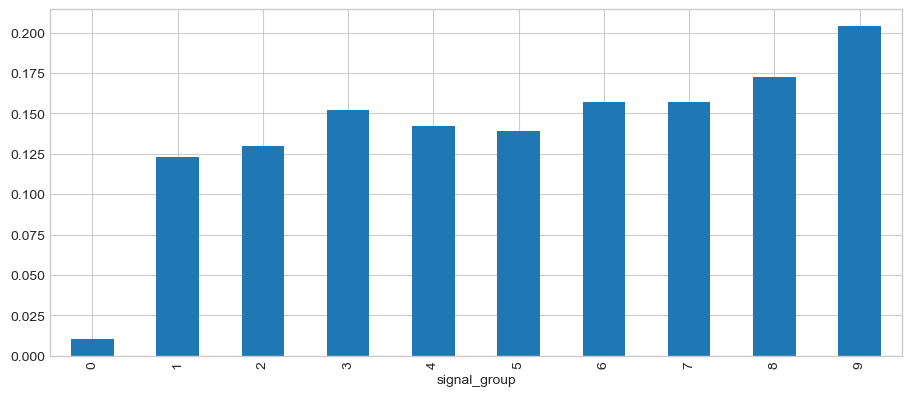

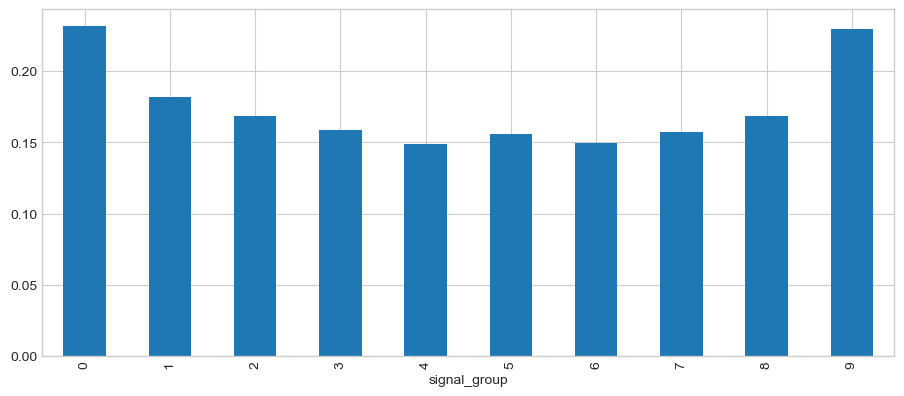

In [ ]:
def portfolio_formation(df,signal,ngroups=10):
    df['signal_group']=df.groupby(['date'])[signal].transform(lambda x: pd.qcut(x, ngroups, labels=False,duplicates='drop'))
    ret =df.groupby(['date','signal_group']).apply(lambda x:(x['ret']*x['me_l1']).sum()/x['me_l1'].sum())
    ret=ret.unstack(level=-1)
    return ret

mom=portfolio_formation(df,'mom',ngroups=10)
(mom.mean()*12).plot.bar()
plt.figure()
(mom.std()*12**0.5).plot.bar()

## Wrapping all in a function that goes from the Return/market cap data to the final signal-sorted portfolio

 Things to try
 - Play with different look-back windows
 - Play with how many months to skip (1 is the minimum to make the strategy valid. 2 is the standard.)
       - What do you think it will happen if you don't skip and let the signal overlap with the return data?
       - What happens if you skip more months?
 - What happens if you sort only on the month that the standard momentum skips?
 - what if you sort on very long-term momentum, like 60 months?
 - Cumulative returns is just one possible moment to look at
   - What about volatility?
   - What about covariance with the market?
   - What about maximum/minimum return?

In [45]:
# put it all together in a fuction
def momentum(df,ngroups=10,lookback=12,extraskip=1):
    df['1+ret']=(df['ret']+1)
    df=df.set_index(['date'])
    temp=(df.groupby('permno')[['1+ret']]).rolling(window=lookback,min_periods=lookback).apply(np.prod, raw=True)
    temp=temp.rename(columns={'1+ret':'signal_contemp'})
    temp =temp.reset_index()
    df = pd.merge(df.reset_index(), temp[['permno','date','signal_contemp']], how='left', on=['permno','date'])
    df=df.sort_values(['date','permno'])
    df['me_l1']=df.groupby('permno')['me'].shift(1)
    df['mom']=df.groupby('permno')['signal_contemp'].shift(1+extraskip)
    df=df.dropna(subset=['mom'], how='any')
    ret=portfolio_formation(df,'mom',ngroups=10)

    return ret


In [46]:
mom=momentum(panel,ngroups=10,lookback=12,extraskip=1)



### Why momentum is lagged twice

The rolling window ends in the month you are standing in, and the signal gets
lagged twice before it sorts anything. The two lags are there for two different
reasons.

1. **Tradability.** The last return in the window is not known until that month
   is over, so a signal ending at month $t$ cannot be used to buy at the start of
   month $t$. Lag once and the signal is complete before the holding month
   begins: no overlap between the returns inside the signal and the return you
   are trying to earn. Skip this and the backtest is not a strategy, it is
   look-ahead.
2. **Short-term reversal.** Lag a second time and the month immediately before
   the holding month drops out of the window too. That month is where reversal
   lives — last month's winners tend to bounce back, which pulls against
   momentum.

Our pipeline already lags every signal by one month before sorting, so the
`.shift(1)` in the code above is the *second* lag. Together the ranking window
runs from t−12 to t−2.

Only the first lag is mandatory. Skipping the second month is an economic
choice, not a correctness requirement — and you are about to see what it is
worth.

### Comparing with the market

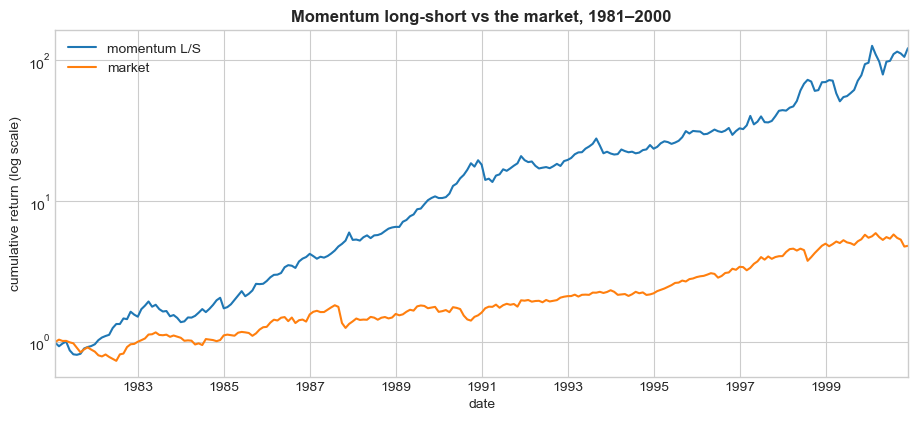

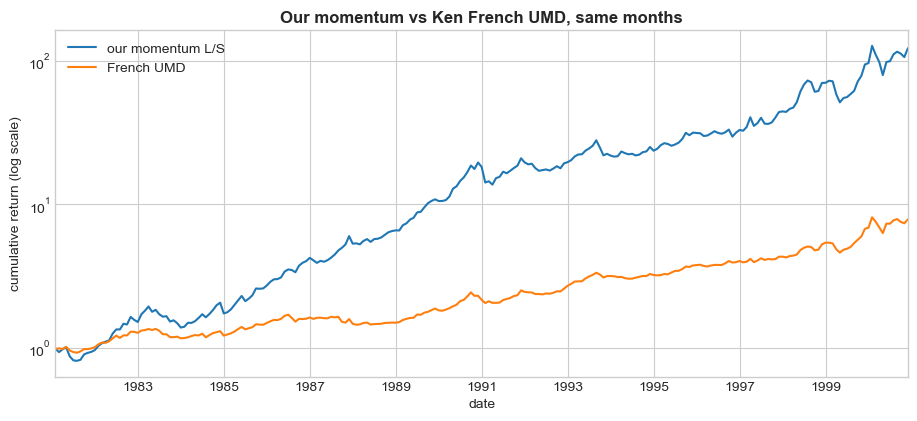

our momentum, 239 months
  raw        +27.27%/yr   t 5.04   Sharpe 1.1282237755533293
  vs market  alpha +26.54%/yr (t 4.83)   beta 0.07923620780575735
239 common months, correlation 0.858

ours   +27.27%/yr   t 5.04   Sharpe 1.13
UMD    +11.14%/yr   t 4.04   Sharpe 0.91

ours on UMD:  alpha +8.48%/yr (t 2.94)   beta +1.69   R² 0.736


In [48]:

# Run the sort — this is our momentum long-short return series
ls = mom[9]-mom[0]
ls=ls.rename('mom10m1')
# Align the strategy with the market's excess return on common months
df = pd.concat([ls, ff['Mkt-RF']], axis=1).dropna()
# Regress the long-short on a constant and the market: intercept = alpha, slope = beta
m = sm.OLS(df.mom10m1, sm.add_constant(df['Mkt-RF'])).fit()



fig, ax = plt.subplots()
(1 + df['mom10m1']).cumprod().plot(ax=ax, label='momentum L/S')
(1 + df['Mkt-RF']).cumprod().plot(ax=ax, label='market')
ax.set_yscale('log')
ax.set_ylabel('cumulative return (log scale)')
ax.set_title('Momentum long-short vs the market, 1981–2000', fontweight='bold')
ax.legend()
plt.show()
# Align our momentum with French's UMD on exactly the same months
df = pd.concat([df, ff['UMD']], axis=1).dropna()



fig, ax = plt.subplots()
(1 + df.mom10m1).cumprod().plot(ax=ax, label='our momentum L/S')
(1 + df.UMD).cumprod().plot(ax=ax, label='French UMD')
ax.set_yscale('log')
ax.set_ylabel('cumulative return (log scale)')
ax.set_title('Our momentum vs Ken French UMD, same months', fontweight='bold')
ax.legend()
plt.show()

print(f"our momentum, {len(df)} months")
# Raw performance: annualized mean, t-stat of the mean, annualized Sharpe ratio
print(f"  raw        {df.mom10m1.mean()*12:+.2%}/yr   t {df.mom10m1.mean()/df.mom10m1.std()*np.sqrt(len(df)):.2f}   "
        f"Sharpe {df.mom10m1.mean()/df.mom10m1.std()*np.sqrt(12)}")
# Market-adddjusted performance: annualized alpha (with its t-stat) and beta
print(f"  vs market  alpha {m.params['const']*12:+.2%}/yr (t {m.tvalues['const']:.2f})   "
        f"beta {m.params['Mkt-RF']}")

print(f"{len(df)} common months, correlation {df.mom10m1.corr(df.UMD):.3f}\n")
print(f"ours   {df.mom10m1.mean()*12:+.2%}/yr   t {df.mom10m1.mean()/df.mom10m1.std()*np.sqrt(len(df)):.2f}   "
        f"Sharpe {df.mom10m1.mean()/df.mom10m1.std()*np.sqrt(12):.2f}")
print(f"UMD    {df.UMD.mean()*12:+.2%}/yr   t {df.UMD.mean()/df.UMD.std()*np.sqrt(len(df)):.2f}   "
        f"Sharpe {df.UMD.mean()/df.UMD.std()*np.sqrt(12):.2f}")

# Regress ours on UMD: if we built the same trade, alpha should be ~0 and beta ~1
m2 = sm.OLS(df.mom10m1, sm.add_constant(df.UMD)).fit()
print(f"\nours on UMD:  alpha {m2.params['const']*12:+.2%}/yr (t {m2.tvalues['const']:.2f})   "
        f"beta {m2.params['UMD']:+.2f}   R² {m2.rsquared:.3f}")

### Two things come out of that

**Correlation 1.000**, on the characteristic and on the strategy. We did not
approximate the file, we reproduced it — the standard to hold your own
constructions to.

**The month counts differ**, 240 against 251. Our momentum needs eleven months of
returns and the panel starts in January 1980, so the first year is warm-up;
theirs was built with data from before the panel begins. Nothing is broken; it is
what building from raw material costs.

And the second lag is worth paying for. Drop it — keep only the tradability lag,
so the ranking window runs to t−1 — and the same strategy earns **+13.5%/yr
instead of +20.0%**. That version is perfectly legitimate: nothing is known that
should not be. It is simply contaminated by the reversal in the month it
includes, which bets against the rest of the position.

---

## 5. The Zoo Is Smaller Than It Looks <a id="smaller"></a>

`long_short()` does not care which column you hand it. Run it on every signal on
the menu, and ask the question the names cannot answer: how many *distinct bets*
are these?

In [49]:
#@title 🔒 Every signal on the menu, and how much they overlap

def long_short(d,signal, ngroups=10):
    p=portfolio_formation(d,signal,ngroups=ngroups)
    return 

R = {}
for name in sorted(menu.Acronym):                 # the menu IS the directory listing
    try:
        x  = pd.read_parquet(f"{BASE}/signals/{name}.parquet")
        dd = panel.merge(x, on=['permno', 'date'], how='left').sort_values(['permno', 'date'])
        dd['sig_l1'] = dd.groupby('permno')[name].shift(1)
        dd['me_l1'] = dd.groupby('permno')['me'].shift(1)
        dd = dd.dropna(subset=['sig_l1', 'ret', 'me_l1'])

        p = portfolio_formation(dd, 'sig_l1', ngroups=10)
        rr=p[9]-p[0]
        if len(rr) > 200: R[name] = rr # build dataframe of long-short returns for each signal
    except Exception:
        pass


L = pd.DataFrame(R).dropna(how='all')

C   = L.corr() # compute pairwise correlations across all signals returns

# build table of correlations within and across economic categories
iu  = np.triu_indices_from(C, 1)
v   = C.values[iu]
nm  = C.columns
cat = menu.set_index('Acronym')['Cat.Economic'].to_dict()
within = [abs(C.values[i, j]) for i, j in zip(*iu) if cat[nm[i]] == cat[nm[j]]]
across = [abs(C.values[i, j]) for i, j in zip(*iu) if cat[nm[i]] != cat[nm[j]]]

print(f"{L.shape[1]} strategies over {len(L)} common months\n")
print(f"  mean pairwise correlation      {v.mean():+.3f}")
print(f"  |corr| > 0.5                   {(np.abs(v) > 0.5).mean():.1%} of pairs\n")
print(f"  mean |corr| WITHIN category    {np.mean(within):.3f}   ({len(within)} pairs)")
print(f"  mean |corr| ACROSS categories  {np.mean(across):.3f}   ({len(across)} pairs)")
pairs = sorted((C.values[i, j], nm[i], nm[j]) for i, j in zip(*iu))
print("\nmost correlated pairs:")
for c, a, b in pairs[-4:][::-1]:
    print(f"  {a:22s} {b:22s} {c:+.2f}")

30 strategies over 251 common months

  mean pairwise correlation      +0.046
  |corr| > 0.5                   10.1% of pairs

  mean |corr| WITHIN category    0.588   (17 pairs)
  mean |corr| ACROSS categories  0.197   (418 pairs)

most correlated pairs:
  IdioVol3F              RealizedVol            +0.96
  MaxRet                 RealizedVol            +0.94
  IdioVol3F              MaxRet                 +0.91
  Illiquidity            Size                   +0.89


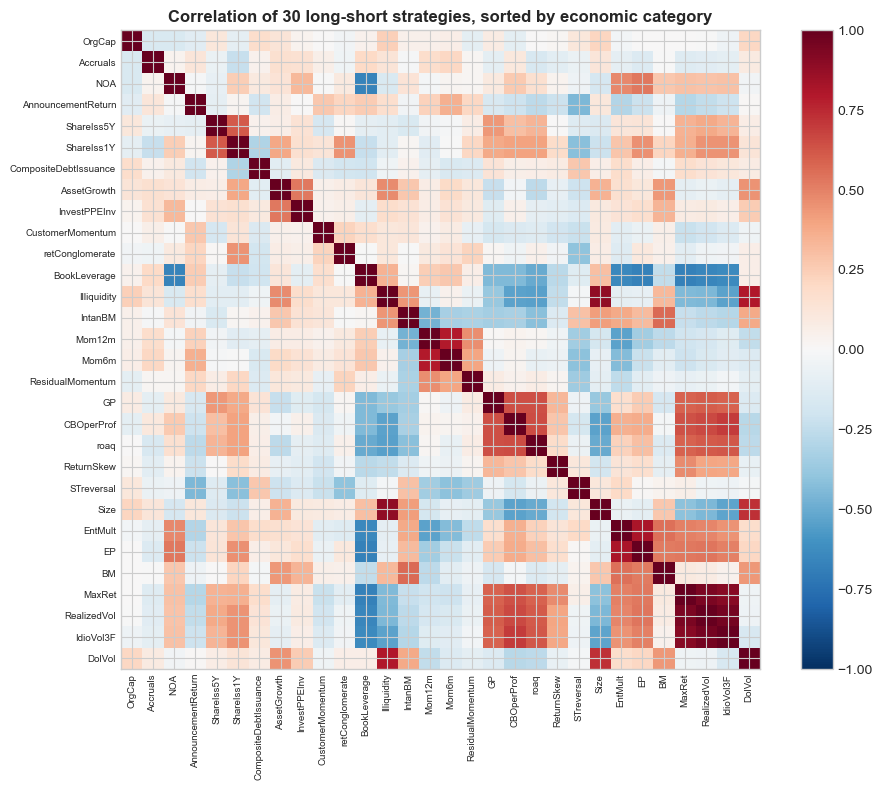

In [42]:
order = (menu.set_index('Acronym').loc[[c for c in C.columns], 'Cat.Economic']
           .sort_values().index.tolist())
fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(C.loc[order, order], cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=90, fontsize=7)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=7)
ax.set_title(f'Correlation of {len(order)} long-short strategies, sorted by economic category',
             fontweight='bold')
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

### Count bets, not papers

The average pairwise correlation is about **+0.04**. Stop there and the zoo looks
wonderfully diversified: thirty-one nearly independent sources of return.

The split says otherwise. **Within an economic category the mean |ρ| is 0.56;
across categories it is 0.18** — and the blocks down the diagonal of the map are
where that lives. MaxRet, RealizedVol and IdioVol3F correlate 0.94 to 0.97:
three papers, two journals, fifteen years apart, one trade.

Illiquidity and Size correlate 0.92 as strategies — and 0.07 as raw
characteristics. That gap is the trap. Correlate the **strategies**, never the
signals: a portfolio is what you own, and two unrelated-looking numbers can sort
stocks the same way.

> **🤖 AI-Era Insight**
>
> Ask an AI to "build a diversified multi-factor strategy" and it will happily
> combine value, size, low-volatility and liquidity — several of which are close
> to the same trade in this sample. It has the names, not the correlation matrix.

> **⚠️ Caution: this breaks a lot of published evidence**
>
> If 300 papers each report an independent-looking discovery, that looks like
> overwhelming support for cross-sectional predictability. If those 300 papers
> are really testing eight or ten distinct bets over and over on overlapping
> samples, it is much weaker support than the headcount suggests. We take that
> apart in Lecture 9, and Lecture 18 asks the sharper version: how many distinct
> factors can this data support *at all*?

---

## 🛠️ Hands-On: Find Your Signal's Twin <a id="ho1"></a>

You picked a signal in Lecture 3 and regressed it in Lecture 4. Now find out what
else it is: pull its row out of the correlation matrix and look at its nearest
neighbours.

If the nearest neighbour is above **+0.8**, you are not holding a distinct bet,
and any "confirmation" from that other signal is not independent evidence. If the
closest is below **+0.3**, your signal is doing something the rest of the zoo is
not — more interesting, and also more suspicious: check that it is not simply
noisier.

In [ ]:
# === EDIT + YOUR TURN ===
MY_SIGNAL = "GP"        # ← your pick from Lecture 3

row = ____              

print(f"{MY_SIGNAL}  ({cat.get(MY_SIGNAL)})\n")
print("closest 5:")
for s, c in row.head(5).items():
    flag = "  ← same family" if cat.get(s) == cat.get(MY_SIGNAL) else ""
    print(f"  {s:24s} {c:+.2f}   {cat.get(s):22s}{flag}")
print("\nmost negatively correlated:")
for s, c in row.tail(3).items():
    print(f"  {s:24s} {c:+.2f}   {cat.get(s)}")

---

## 🎯 Challenge: Does Beta Explain It? <a id="challenge"></a>

*Homework — due before Lecture 6.*

Two signals: `BookLeverage` and `IdioVol3F`. For each, find out whether its spread
in average returns is anything more than a spread in beta — and what that means
for someone who already holds the market.

### Q1 — Ten portfolios, their betas, and the long-short

For each signal, sort the way this lecture's `long_short()` does — signal lagged
one month, NYSE breakpoints, value-weighted by `me_l1` — but put breakpoints at
every tenth percentile (10th, 20th, …, 90th) and keep **all ten** portfolios.
Every stock goes into the portfolio its signal falls in, NYSE or not.

Subtract the T-bill rate (`ff['RF']`) from each portfolio's return and regress it
on the market's excess return (`ff['Mkt-RF']`), 1980–2000.

Then form the long-short, portfolio 10 minus portfolio 1, and regress it on the
market too. The T-bill rate cancels in a long-short, so do not subtract it again.

Write it once as a function and run it on both signals.

> **📌 Required variable names**, for each signal (`_bl` for BookLeverage, `_iv`
> for IdioVol3F):
> ```python
> betas_bl   = ____   # 10 values: market beta of portfolios 1 to 10
> avg_bl     = ____   # 10 values: average excess return, annualized
> ls_beta_bl = ____   # 10 - 1: market beta
> ls_avg_bl  = ____   # 10 - 1: average return, annualized
> ls_t_bl    = ____   # 10 - 1: t-statistic of its alpha
> ```

In [ ]:
# Your work here


# Required outputs — fill these in:
betas_bl   = ____
avg_bl     = ____
ls_beta_bl = ____
ls_avg_bl  = ____
ls_t_bl    = ____

betas_iv   = ____
avg_iv     = ____
ls_beta_iv = ____
ls_avg_iv  = ____
ls_t_iv    = ____

for name, b, a, lb, la, lt in [('BookLeverage', betas_bl, avg_bl, ls_beta_bl, ls_avg_bl, ls_t_bl),
                               ('IdioVol3F',    betas_iv, avg_iv, ls_beta_iv, ls_avg_iv, ls_t_iv)]:
    print(name)
    print(pd.DataFrame({'beta': np.asarray(b), 'avg excess return': np.asarray(a)},
                       index=range(1, 11)).round(3).to_string())
    print(f"  10 - 1:  beta {lb:+.2f}   average {la:+.2%}/yr   alpha t = {lt:+.2f}\n")

### Q2 — The picture

Two panels, one per signal. In each, plot beta on the x-axis against average
excess return on the y-axis for the ten portfolios, labelled 1 to 10. Add the
**long-short** 10 − 1 as a different marker, and the **market**. What is the
market's beta?

> **📌 Required variable name:**
> ```python
> mkt_avg = ____   # the market's average excess return, annualized, same months
> ```

In [ ]:
# Required output — fill this in:
mkt_avg = ____

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Your plot here: in each panel the ten portfolios (labelled 1-10),
# the 10 - 1 long-short, and the market


for ax, name in zip(axes, ['BookLeverage', 'IdioVol3F']):
    ax.set_title(name); ax.set_xlabel('market beta')
axes[0].set_ylabel('average excess return, annualized')
plt.tight_layout(); plt.show()

### Q3 — The memo

> **📝 Your task — maximum 6 sentences**
>
> Describe what you see in each plot. Do average returns line up with beta?
> Where does each long-short sit?
>
> Then: an investor is fully invested in the market and wants a higher Sharpe
> ratio. What does each plot tell them to do?
>
> *Hint: what could that investor already get by holding more or less of the
> market — or even shorting it — and keeping the rest in T-bills? Where would
> that put them on your plots?*

In [ ]:
MEMO = """
Write your memo here. Don't delete the surrounding triple quotes.
"""
print(MEMO)

---

## 📤 Submission <a id="submit"></a>

In [ ]:
# === 📤 SUBMISSION CELL — Run this last ===
import json, base64, hashlib, datetime as dt

required = ["betas_bl", "avg_bl", "ls_beta_bl", "ls_avg_bl", "ls_t_bl",
            "betas_iv", "avg_iv", "ls_beta_iv", "ls_avg_iv", "ls_t_iv",
            "mkt_avg", "MEMO"]
missing = [v for v in required if v not in globals()]
if missing:
    raise NameError(f"\n❌ Missing before submission: {missing}")
lists = ["betas_bl", "avg_bl", "betas_iv", "avg_iv"]
if any(len(np.ravel(eval(k))) != 10 for k in lists):
    raise ValueError("\n❌ betas_* and avg_* should each hold ten numbers, portfolios 1 to 10")

payload = {
    "assignment": "L5_FactorZoo_AI",
    "ts": dt.datetime.now(dt.timezone.utc).isoformat(timespec="seconds").replace("+00:00", "Z"),
    "answers": {k: ([float(x) for x in np.ravel(eval(k))] if k in lists else float(eval(k)))
                for k in required if k != "MEMO"},
    "memo": MEMO.strip(),
}
blob = json.dumps(payload, sort_keys=True)
checksum = hashlib.sha256(blob.encode()).hexdigest()[:8]
token = f"UG54::{checksum}::{base64.b64encode(blob.encode()).decode()}"

print("=" * 72)
print("📋  COPY THE LINE BELOW AND PASTE INTO THE SUBMISSION FORM")
print("=" * 72)
print(token)
print("=" * 72)
print("Submission form: https://forms.gle/yazZ8bbatL87jdJi7")

---

## 🧠 Key Takeaways <a id="takeaways"></a>

1. **Three kinds of factor model**, distinguished by what you specify:
   time-series (you name the factor returns), characteristic (you name the
   exposures), statistical (you name nothing).

2. **A sort makes a factor; a regression consumes one.** Same raw material,
   opposite direction.

3. **Every family has two stories, risk and mispricing**, and they predict
   different futures. Mispricing implies the premium dies after publication.

4. **A price ratio has to forecast something** — expected return or cash-flow
   growth, there is nothing else it can be. A lead-lag signal has no identity
   behind it; it is a claim about attention.

5. **You can build a factor from returns alone.** Momentum, the t−12 to t−2
   return, sorted and value-weighted: +20%/yr in this sample.

6. **Two lags, two reasons.** One makes the signal tradable — without it you have
   look-ahead, not a strategy. The second skips the reversal month, and it is
   worth 6.5 points a year here.

7. **A spread in average returns is not a new factor.** It adds something only if
   its alpha against the factors you already hold is nonzero:
   $SR_{\max}^2 = SR_m^2 + (\alpha/\sigma_\varepsilon)^2$.

8. **Correlate the strategies, never the signals.** Within a family mean |ρ| ≈
   0.56, across families ≈ 0.18, so diversification comes from spanning families.
   And 300 papers is not 300 pieces of evidence.

---

### Next class

We've been using one factor — the market. Next: how to run and read a model with
several, why alpha shrinks every time you add one, and the two different ways to
estimate the whole thing.

---

## 📎 Appendix <a id="appendix"></a>

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# 📎 APPENDIX — data
# ═══════════════════════════════════════════════════════════════════════
# Everything today comes from the repo:
#   panel  = pd.read_parquet(f"{BASE}/panel_backbone_1980_2000.parquet")
#   signal = pd.read_parquet(f"{BASE}/signals/<Acronym>.parquet")
#   menu   = pd.read_csv(f"{BASE}/signal_menu.csv")
#
# The 32 signals are replications from Open Source Asset Pricing
# (Chen & Zimmermann), which covers 300+ published cross-sectional predictors:
#     https://www.openassetpricing.com
# `signal_menu.csv` carries each one's authors, year, journal, economic
# category, and the t-statistic the ORIGINAL paper reported — which is what
# makes the replication comparison in Lecture 3 possible.
